In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so

from formulaic import Formula

# Herramientas de modelos lineales
from sklearn import linear_model  

# Medidas de desempeño
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error    

# Descarga gapminder
url = "https://raw.githubusercontent.com/resbaz/r-novice-gapminder-files/master/data/gapminder-FiveYearData.csv"
gapminder = pd.read_csv(url)

# Regresión Polinomial

Buscamos los coeficientes de un polinomio de grado $n$
$$Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \dots + \beta_n X^n$$

que mejor aproxime a nuestros datos en el sentido de Cuadrados Mínimos. Es decir, buscamos $\beta_1,\dots, \beta_n$ que minimicen:
$$ RSS(\beta) = \displaystyle\sum_{i=1}^n (y_i - P(x_i))^2 $$

Vamos a usar como ejemplo los datos de PBI per capita de Argentina, del dataset `gapminder`

In [2]:
gapminder

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106
...,...,...,...,...,...,...
1699,Zimbabwe,1987,9216418.0,Africa,62.351,706.157306
1700,Zimbabwe,1992,10704340.0,Africa,60.377,693.420786
1701,Zimbabwe,1997,11404948.0,Africa,46.809,792.449960
1702,Zimbabwe,2002,11926563.0,Africa,39.989,672.038623


In [3]:
datos_arg = gapminder[gapminder['country'] == 'Argentina'].reset_index(drop=True)
datos_arg

,country,year,pop,continent,lifeExp,gdpPercap
0,Argentina,1952,17876956.0,Americas,62.485,5911.315053
1,Argentina,1957,19610538.0,Americas,64.399,6856.856212
2,Argentina,1962,21283783.0,Americas,65.142,7133.166023
3,Argentina,1967,22934225.0,Americas,65.634,8052.953021
4,Argentina,1972,24779799.0,Americas,67.065,9443.038526
5,Argentina,1977,26983828.0,Americas,68.481,10079.026740
6,Argentina,1982,29341374.0,Americas,69.942,8997.897412
7,Argentina,1987,31620918.0,Americas,70.774,9139.671389
8,Argentina,1992,33958947.0,Americas,71.868,9308.418710
9,Argentina,1997,36203463.0,Americas,73.275,10967.281950


## Visualización

Teníamos la visualización de la Regresión Lineal:

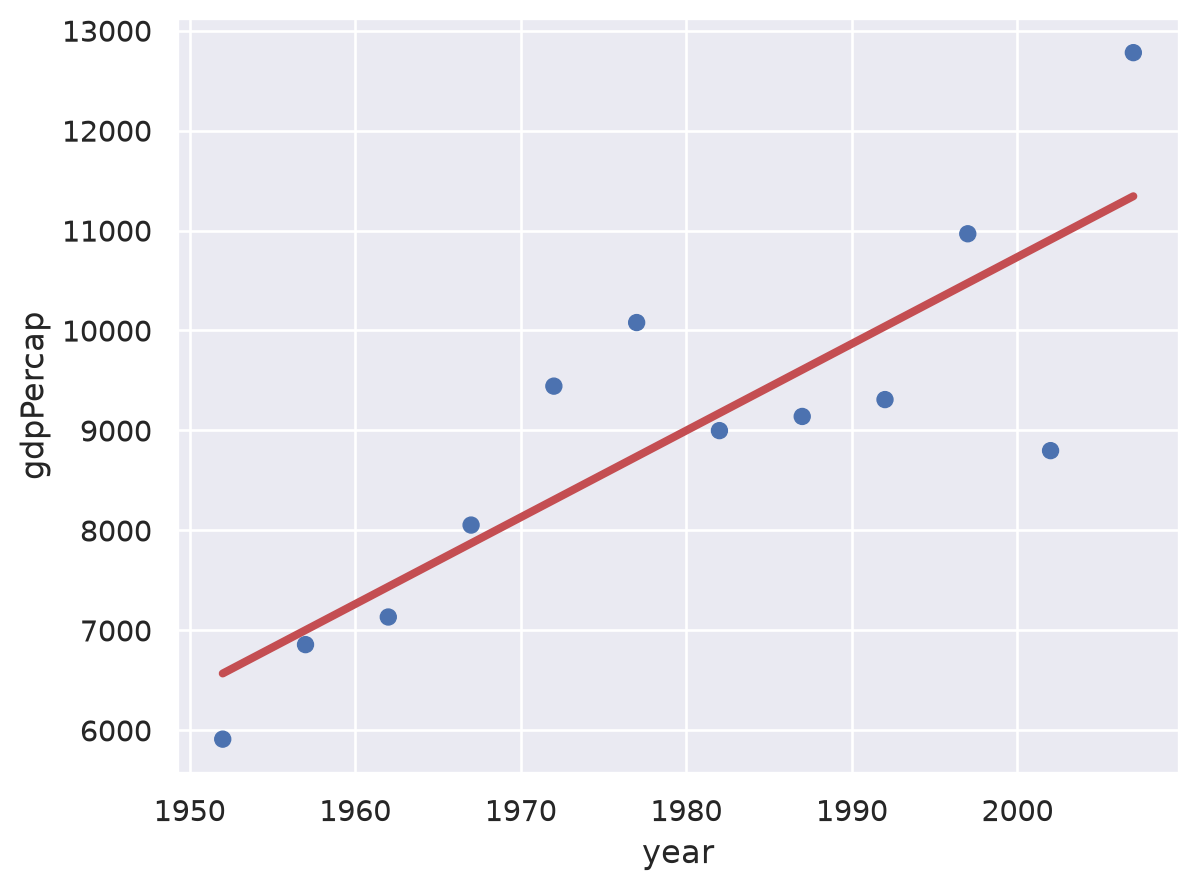

In [4]:
(
    so.Plot(data=datos_arg, x='year', y='gdpPercap')
    .add(so.Dot())
    .add(so.Line(color='r', linewidth=3), so.PolyFit(1))
)

Calculemos el $R^2$ de la Regresión Lineal:

In [5]:
# Escribimos la fórmula
y, X = Formula('gdpPercap ~ year').get_model_matrix(datos_arg)

# Inicializamos el modelo de regresión
modelo = linear_model.LinearRegression(fit_intercept=False)

# Realizamos el ajuste
modelo.fit(X, y)

# Calculamos R²
y_pred = modelo.predict(X)
r2_score(datos_arg['gdpPercap'], y_pred)

0.7060056670920903

Para cambiar el grado del polinomio que ajusta los datos en Seaborn, simplemente cambios el argumento de `so.PolyFit`. Por ejemplo, para un polinomio de grado $???$:

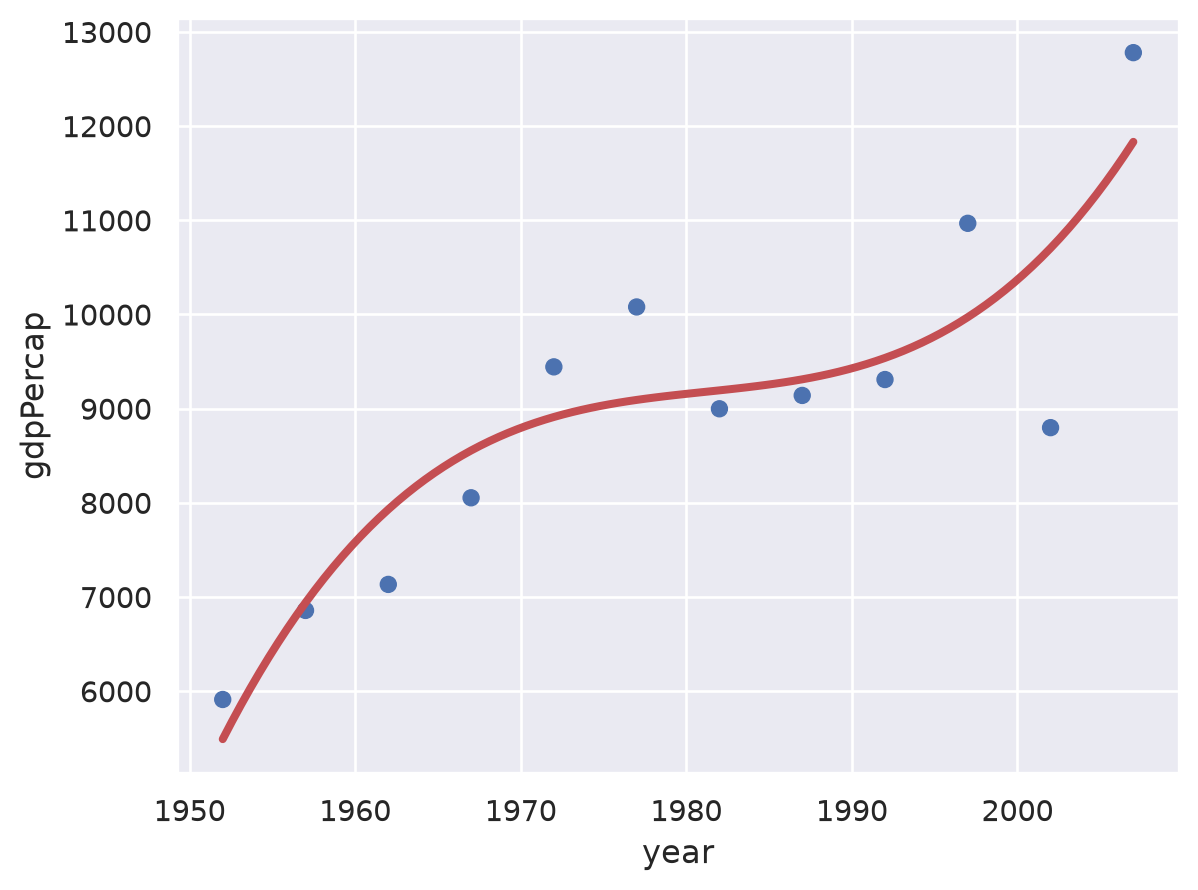

In [6]:
(
    so.Plot(data=datos_arg, x=datos_arg['year'], y='gdpPercap')
    .add(so.Dot())
    .add(so.Line(color='r', linewidth=3), so.PolyFit(3))
)

## Cálculo de coeficientes y de predicciones

Queremos buscar el polinomio de grado 3 que mejor aproxima a los datos en sentido de cuadrados mínimos:
$$P(x) = \beta_0 + \beta_1 x + \beta_2 x^ 2 + \beta_3 x^ 3$$

Calcularemos los coeficientes con `scikit-learn`. Es parecido a lo que hacíamos con la regresión lineal, pero con un paso extra: tenemos que construir la matriz de datos agregando columnas para $x^2$ y $x^3$.

## Formulaic: implementación de alto rendimiento de las fórmulas de Wilkinson para Python

Aunque perfectamente podemos hacer la matriz "a mano", el paquete Formulaic nos permite hacerla automáticamente para polinomios de cualquier grado.

In [7]:
# poly(year,3) significa que usamos un polinomio de grado 3 cuya variable es year
# raw = True nos da los datos "crudos", es decir genera columnas x, x^2 y x^3 sin ninguna transformación ni normalización.
# -1 significa que no queremos una columna de 1's en la matriz para el intercept

y, X = Formula('gdpPercap ~ poly(year, 3, raw=True) - 1').get_model_matrix(datos_arg)
y = y.iloc[:, 0]  # Convertimos el DataFrame a Series

In [8]:
X

,"poly(year, 3, raw=True)[0]","poly(year, 3, raw=True)[1]","poly(year, 3, raw=True)[2]"
0,1952,3810304,7437713408
1,1957,3829849,7495014493
2,1962,3849444,7552609128
3,1967,3869089,7610498063
4,1972,3888784,7668682048
5,1977,3908529,7727161833
6,1982,3928324,7785938168
7,1987,3948169,7845011803
8,1992,3968064,7904383488
9,1997,3988009,7964053973


In [9]:
y

0      5911.315053
1      6856.856212
2      7133.166023
3      8052.953021
4      9443.038526
5     10079.026740
6      8997.897412
7      9139.671389
8      9308.418710
9     10967.281950
10     8797.640716
11    12779.379640
Name: gdpPercap, dtype: float64

In [10]:
# Inicializamos el modelo de regresión. 
modelo = linear_model.LinearRegression(fit_intercept=True)

# Realiza el ajuste
modelo.fit(X, y)

# Como usamos fit_intercept = True, la ordenada al origen está en modelo.intercept_
ordenada_al_origen = modelo.intercept_

# Recuperamos los valores de los demas coeficientes (de menor potencia a la mayor)
coeficientes = modelo.coef_

# Armamos el array con los valores de beta
beta = np.array([ordenada_al_origen, *coeficientes])

# Imprimimos los valores:
print('beta_0: ', beta[0])
print('beta_1: ', beta[1])
print('beta_2: ', beta[2])
print('beta_3: ', beta[3])

beta_0:  -932252.5201352356
beta_1:  0.0003419321804294898
beta_2:  0.6768324545124507
beta_3:  -0.00022055246565277908


El polinomio de grado a lo sumo 3 que mejor aproxima a los datos es:
$$P(x) = -984937719.58 + 1491410.41 x -752.77 x^ 2 + 0.12 x^ 3 $$

Corroboremos que el gráfico de este polinomio es el mismo que arma `seaborn` con `so.PolyFit`: --> **no va a ser así (ver observación)**

In [11]:
X

,"poly(year, 3, raw=True)[0]","poly(year, 3, raw=True)[1]","poly(year, 3, raw=True)[2]"
0,1952,3810304,7437713408
1,1957,3829849,7495014493
2,1962,3849444,7552609128
3,1967,3869089,7610498063
4,1972,3888784,7668682048
5,1977,3908529,7727161833
6,1982,3928324,7785938168
7,1987,3948169,7845011803
8,1992,3968064,7904383488
9,1997,3988009,7964053973


In [12]:
y_pred = modelo.predict(X)
y_pred

array([ 6279.52512185,  6870.32157363,  7430.21647184,  7959.04440214,
        8456.63995017,  8922.83770158,  9357.47224203,  9760.37815717,
       10131.39003265, 10470.34245411, 10777.07000722, 11051.40727761])

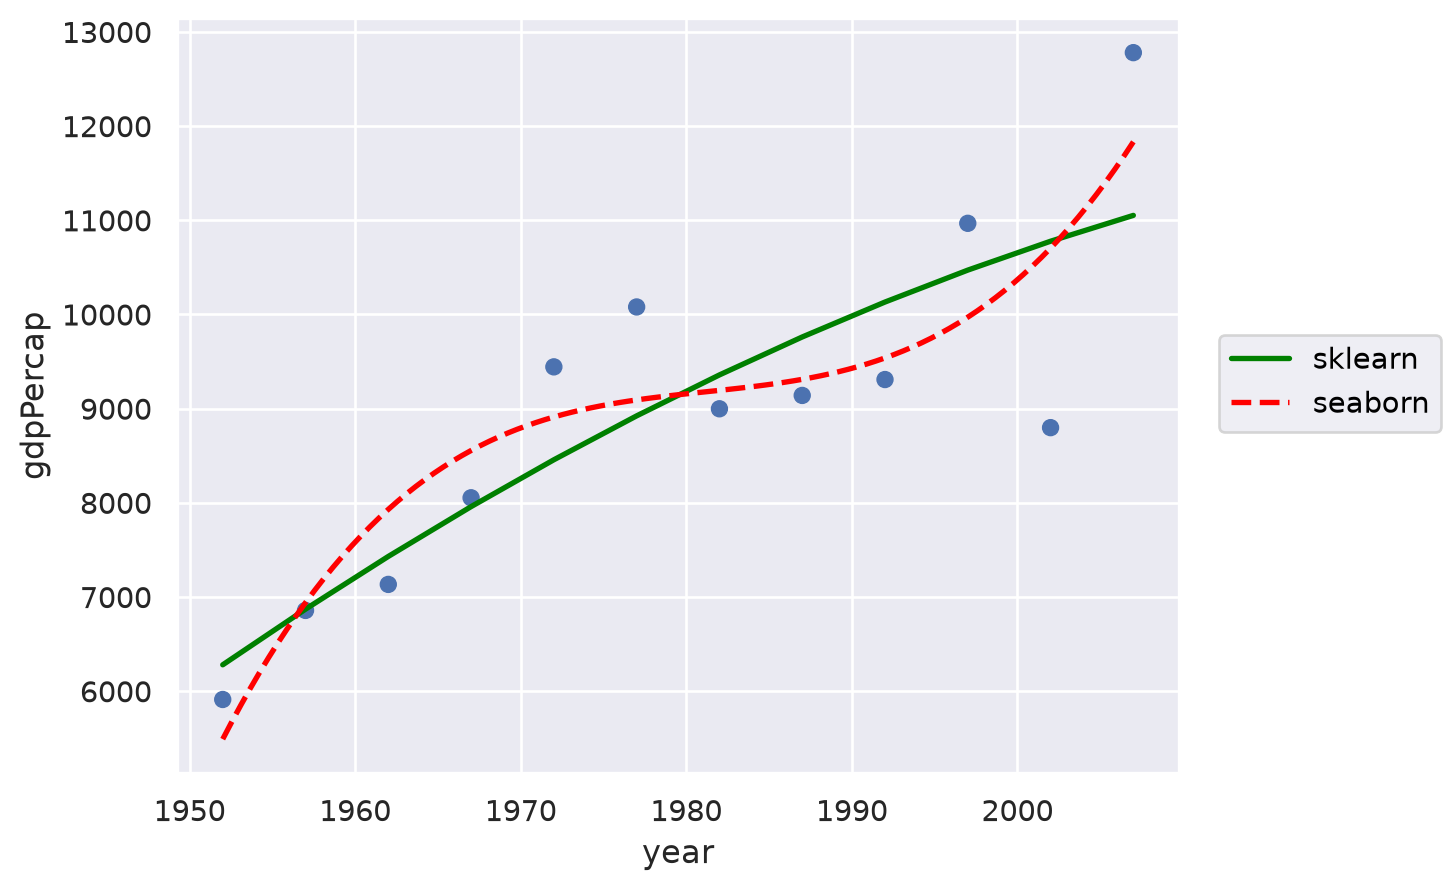

In [13]:
(
    so.Plot(data = datos_arg, x = 'year', y = 'gdpPercap')
    .add(so.Dot())
    .add(so.Line(color = 'green', linewidth=2), y = y_pred, label = 'sklearn')
    .add(so.Line(color = 'red', linestyle = '--', linewidth = 2), so.PolyFit(3), label = 'seaborn')
    .label()
)

Igual que antes, podemos estimar el PBI per capita, por ejemplo para 1990 y 2015:

* haciendo las cuentas

In [14]:
# Haciendo las cuentas a mano
prediccion_1990 = beta[0] + beta[1]*1990 + beta[2]*(1990**2) + beta[3]*(1990**3)

# O usando numpy
prediccion_2015 = beta @ 2015**np.arange(4, dtype='int64')

print('Prediccion 1990: ', prediccion_1990)
print('Prediccion 2015: ', prediccion_2015)

Prediccion 1990:  9986.823153734207
Prediccion 2015:  11422.562247987604


* usando `predict`

In [15]:
# Armamos un DataFrame con los datos de x a los cuales les queremos aplicar el modelo
nuevos = pd.DataFrame({"year":  [1990, 2015]})

# Armamos el DataFrame para pasarle a predict
datos_a_predecir = Formula('gdpPercap ~ poly(year, 3, raw=True) - 1').rhs.get_model_matrix(nuevos)   #rhs (right hand side) nos da solo x
datos_a_predecir

,"poly(year, 3, raw=True)[0]","poly(year, 3, raw=True)[1]","poly(year, 3, raw=True)[2]"
0,1990,3960100,7880599000
1,2015,4060225,8181353375


In [16]:
modelo.predict(datos_a_predecir)

array([ 9986.82315373, 11422.56224799])

También podemos calcular las medidas de desempeño del modelo:

In [17]:
y_pred = modelo.predict(X)

# Calculando el R^2
r2 = r2_score(datos_arg['gdpPercap'], y_pred)
print('R^2: ', r2)

# Calculando el ECM
ecm = mean_squared_error(datos_arg['gdpPercap'], y_pred)
print('ECM: ', ecm)

# Calculando la RECM
recm = root_mean_squared_error(datos_arg['gdpPercap'], y_pred)
print('RECM: ', recm)

R^2:  0.7147533820700207
ECM:  907116.9522178938
RECM:  952.4268749977049


### Observación
El gráfico de la regresión con seaborn vs la regresión con scikit learn no es igual. Despues de unas pruebas pude comprobar que si en la fórmula pongo _Formula('gdpPercap ~ poly(year, 3, **raw = False**) - 1')_ y no "raw = True" como está originalmente en el notebook, los gráficos si son prácticamente iguales. Entiendo que algo hace la normalización de los datos que provoca un mejor resultado. 

In [18]:
# Planteo la fórmula
y, X = Formula('gdpPercap ~ poly(year, 3, raw = False) - 1').get_model_matrix(datos_arg) # EL CAMBIO LO HAGO ACÁ
y = y.iloc[:, 0]

# Inicializamos el modelo de regresión. 
modelo2 = linear_model.LinearRegression(fit_intercept=True)

# Realiza el ajuste
modelo2.fit(X, y)

# Como usamos fit_intercept = True, la ordenada al origen está en modelo.intercept_
ordenada_al_origen = modelo2.intercept_

# Recuperamos los valores de los demas coeficientes (de menor potencia a la mayor)
coeficientes = modelo2.coef_

# Armamos el array con los valores de beta
beta = np.array([ordenada_al_origen, *coeficientes])

# Imprimimos los valores:
print('beta_0: ', beta[0])
print('beta_1: ', beta[1])
print('beta_2: ', beta[2])
print('beta_3: ', beta[3])

beta_0:  8955.553782666666
beta_1:  5190.582596203027
beta_2:  -586.5292072895488
beta_3:  1703.8790825904769


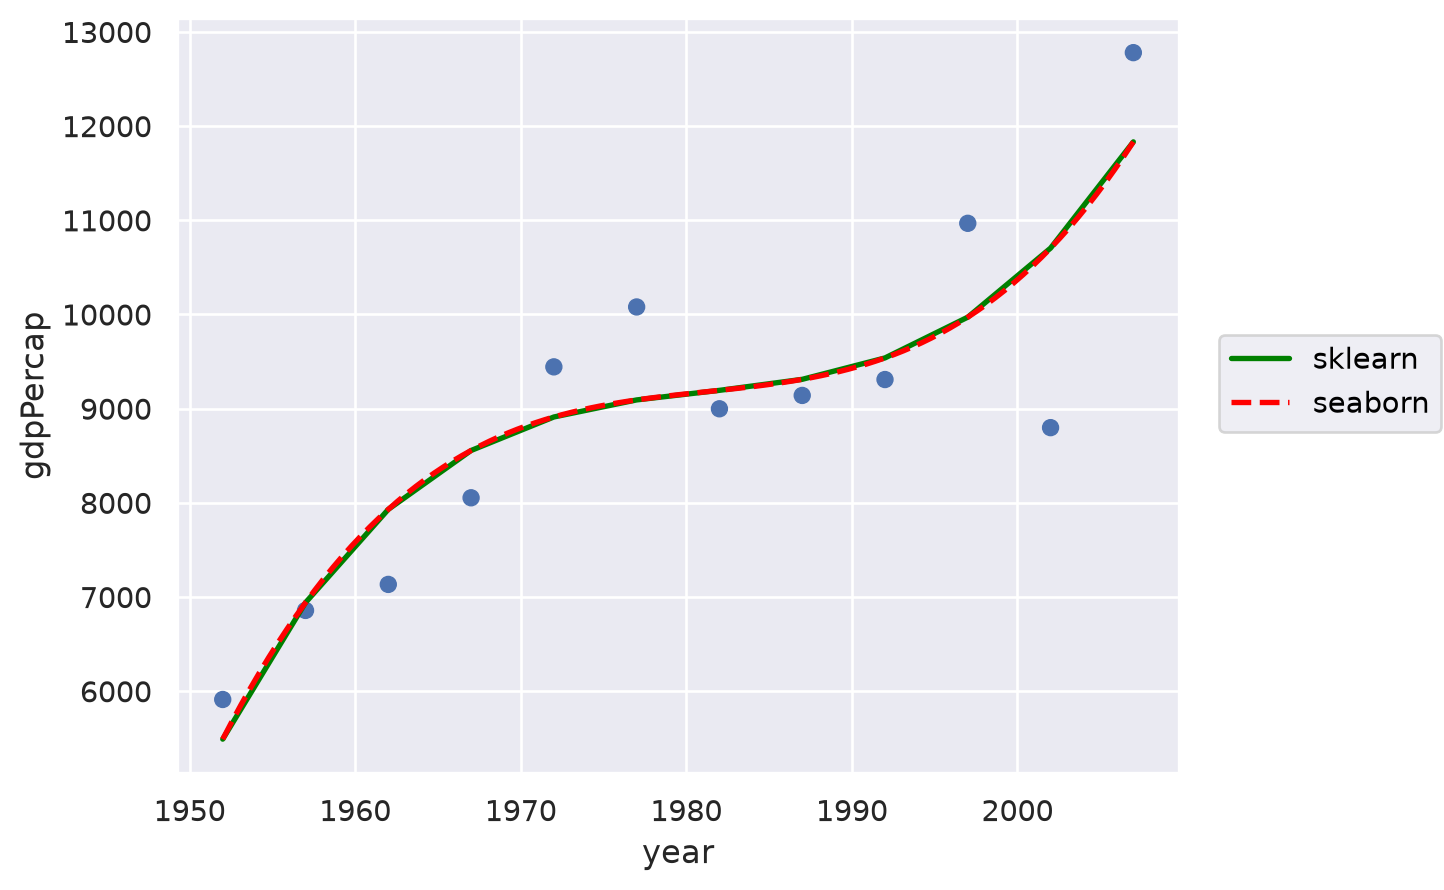

In [19]:
# Vuelvo a predecir los resultados
y_pred = modelo2.predict(X)

# Grafico
(
    so.Plot(data = datos_arg, x = 'year', y = 'gdpPercap')
    .add(so.Dot())
    .add(so.Line(color = 'green', linewidth=2), y = y_pred, label = 'sklearn')
    .add(so.Line(color = 'red', linestyle = '--', linewidth = 2), so.PolyFit(3), label = 'seaborn')
    .label()
)

In [20]:
# Calculando el R^2
r2 = r2_score(datos_arg['gdpPercap'], y_pred)
print('R^2: ', r2)

# Calculando el ECM
ecm = mean_squared_error(datos_arg['gdpPercap'], y_pred)
print('ECM: ', ecm)

# Calculando la RECM
recm = root_mean_squared_error(datos_arg['gdpPercap'], y_pred)
print('RECM: ', recm)

R^2:  0.791097474131571
ECM:  664333.985628205
RECM:  815.0668596061338


Según Claude: _**La diferencia no es matemática sino numérica**. Ambas versiones deberían dar el mismo resultado en teoría, pero `raw = True` falla en la práctica por cómo están escalados los datos. Los errores de punto flotante acumulados son suficientemente grandes como para producir coeficientes distintos y una curva visualmente diferente. Con `raw = False`, los valores están en una escala similar entre sí y son ortogonales → el sistema lineal está bien condicionado → la solución numérica coincide con la matemática. `raw = False` genera polinomios ortogonales (proceso de Gram-Schmidt): transforma internamente los valores de year centrándolos y construyendo una base donde cada columna es ortogonal a las demás. Los valores resultantes son todos pequeños y bien condicionados._

## Regresión con funciones bases

Vamos a trabajar con mediciones de dióxido de carbono en el aire en el observatorio de Mauna Loa (Hawaii)

In [21]:
# Cargamos los datos y graficamos
data = pd.read_csv('../data/co2_hawaii.csv')
data

,fecha,co2
0,1958-03-31,316.100000
1,1958-04-30,317.200000
2,1958-05-31,317.433333
3,1958-07-31,315.625000
4,1958-08-31,314.950000
...,...,...
516,2001-08-31,369.425000
517,2001-09-30,367.880000
518,2001-10-31,368.050000
519,2001-11-30,369.375000


In [22]:
# Tomamos la fecha como indice
data = data.set_index("fecha")
data

,co2
fecha,
1958-03-31,316.100000
1958-04-30,317.200000
1958-05-31,317.433333
1958-07-31,315.625000
1958-08-31,314.950000
...,...
2001-08-31,369.425000
2001-09-30,367.880000
2001-10-31,368.050000


In [23]:
type(data)

pandas.DataFrame

<Axes: xlabel='fecha'>

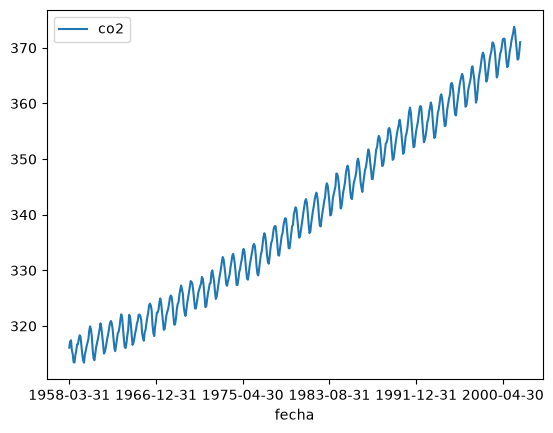

In [24]:
# Graficamos
data.plot()

Queremos ajustar a los datos una función de la forma
$$
co2 = \beta_0 + \beta_1 * mes + \beta_2 * \sin\left(2 \pi *  \frac{mes}{12}\right)
$$

Construimos una matriz $X$ con una columna para el mes y otra columna para el seno.

In [25]:
# ¿Cuántos meses hay en los datos?
data.co2.size

521

In [26]:
mes = np.arange(521)
datos_transformados = pd.DataFrame(
    {
        "mes": mes,
        "sinx": np.sin(2 * np.pi * mes/12),
        "co2": data["co2"]
    },
    index=data.index
)
datos_transformados

,mes,sinx,co2
fecha,,,
1958-03-31,0,0.000000e+00,316.100000
1958-04-30,1,5.000000e-01,317.200000
1958-05-31,2,8.660254e-01,317.433333
1958-07-31,3,1.000000e+00,315.625000
1958-08-31,4,8.660254e-01,314.950000
...,...,...,...
2001-08-31,516,-1.763739e-14,369.425000
2001-09-30,517,5.000000e-01,367.880000
2001-10-31,518,8.660254e-01,368.050000


In [27]:
# Ajustamos el modelo

y, X = Formula('co2 ~ mes + sinx').get_model_matrix(datos_transformados)
y = y.iloc[:, 0]  # Convertimos el DataFrame a Series

# Inicializamos el modelo de regresión
modeloCO2 = linear_model.LinearRegression(fit_intercept=True)

# Realizamos el ajuste
modeloCO2.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0. , 0.11,-2.27]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Intercept','mes','sinx']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,310.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [28]:
# Predecimos
y_pred = modeloCO2.predict(X)

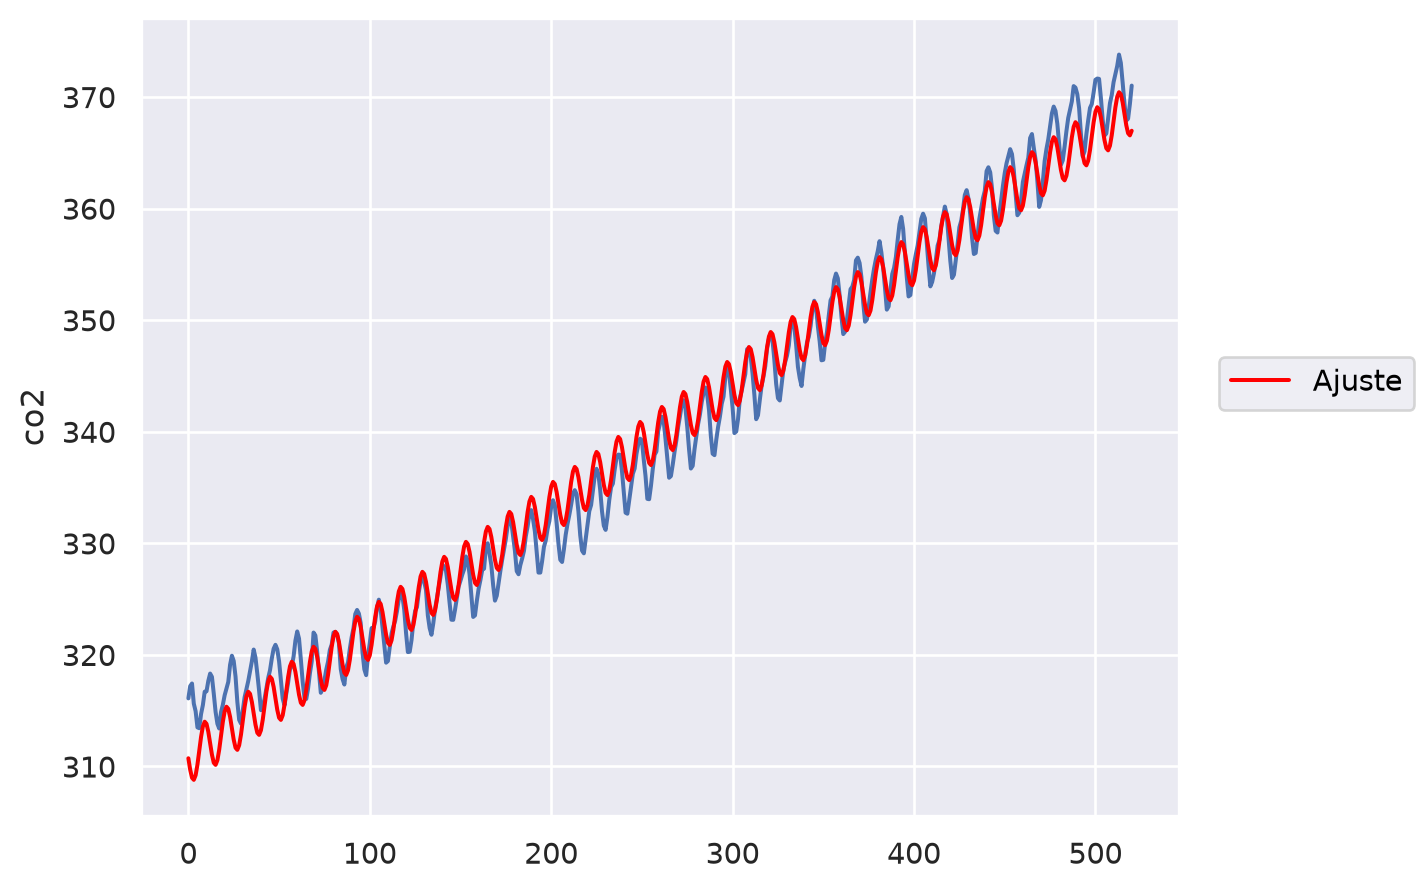

In [29]:
# Graficamos
(
    so.Plot()  # Podemos usar también x = data.index pero no se ve bien
    .add(so.Line(), data=data, x = mes, y="co2")
    .add(so.Line(color = "red"), x=mes, y=y_pred, label='Ajuste')
)

In [30]:
# Calculando el R^2
r2 = r2_score(data["co2"], y_pred)
print('R^2: ', r2)

R^2:  0.984074298149345


## Residuos
El $R^2$ nos dio muy bien! Se podrá mejorar?
Veamos los residuos...

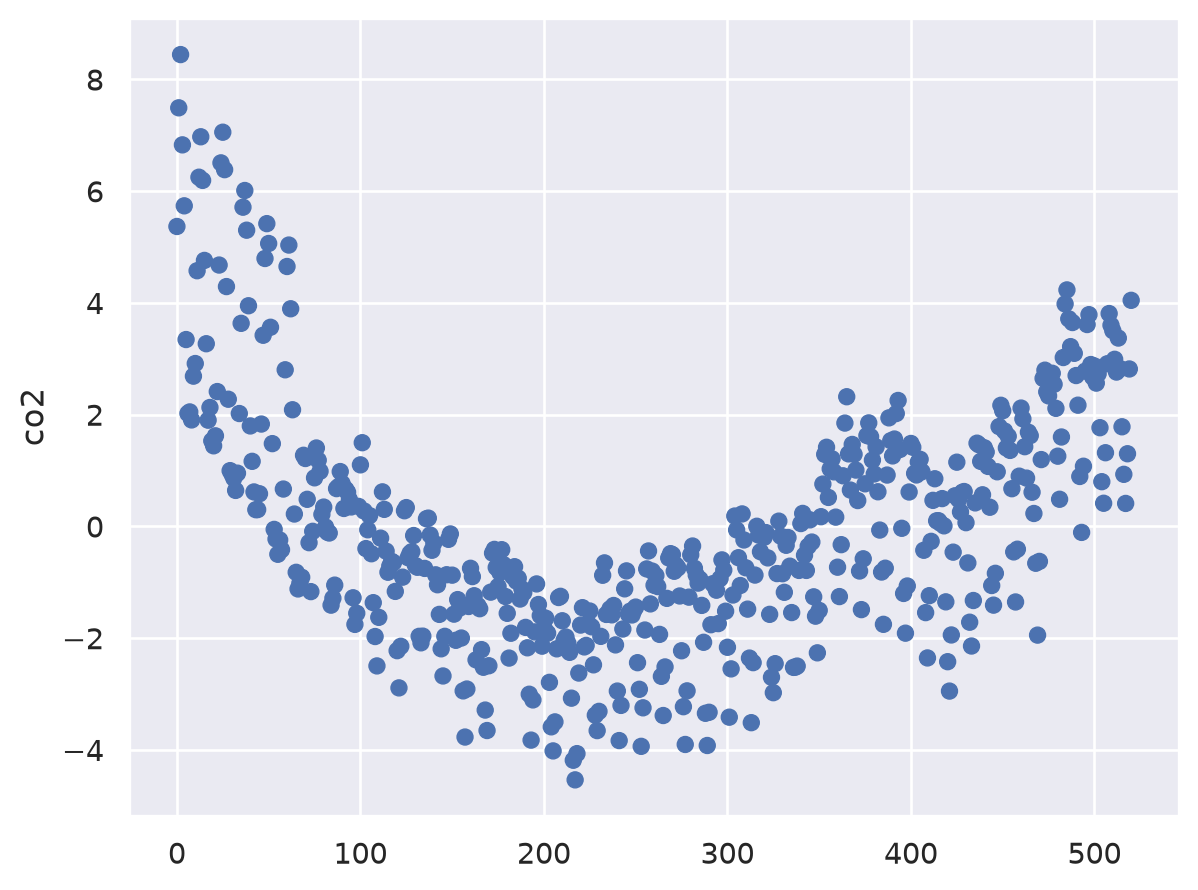

In [31]:
residuos = data["co2"] - y_pred
(
    so.Plot(x=mes, y=residuos)
    .add(so.Dot())
)

Los residuos no parecen al azar... ¡podemos mejorar el ajuste!

## Ejercicio

Agregar otras funciones base al modelo y ver si mejora el ajuste en el gráfico y el $R^2$.

Recordar que solo podemos usar una combinación lineal de funciones base.

En el gáfico de residuos veo que los mismos parecen comportarse cuadráticamente, pruebo sumarle al modelo un término cuadrático.

In [32]:
# Ajustamos el modelo

y, X = Formula('co2 ~ mes + poly(mes, 2, raw=True) + sinx').get_model_matrix(datos_transformados)
y = y.iloc[:, 0]  # Convertimos el DataFrame a Series

# Inicializamos el modelo de regresión
modeloCO2_mejorado = linear_model.LinearRegression(fit_intercept=True)

# Realizamos el ajuste
modeloCO2_mejorado.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0. , 0.03, 0.03, 0. ,-2.32]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Intercept','mes','poly(mes, 2, raw=True)[0]','poly(mes, 2, raw=True)[1]', 'sinx']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,314.4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


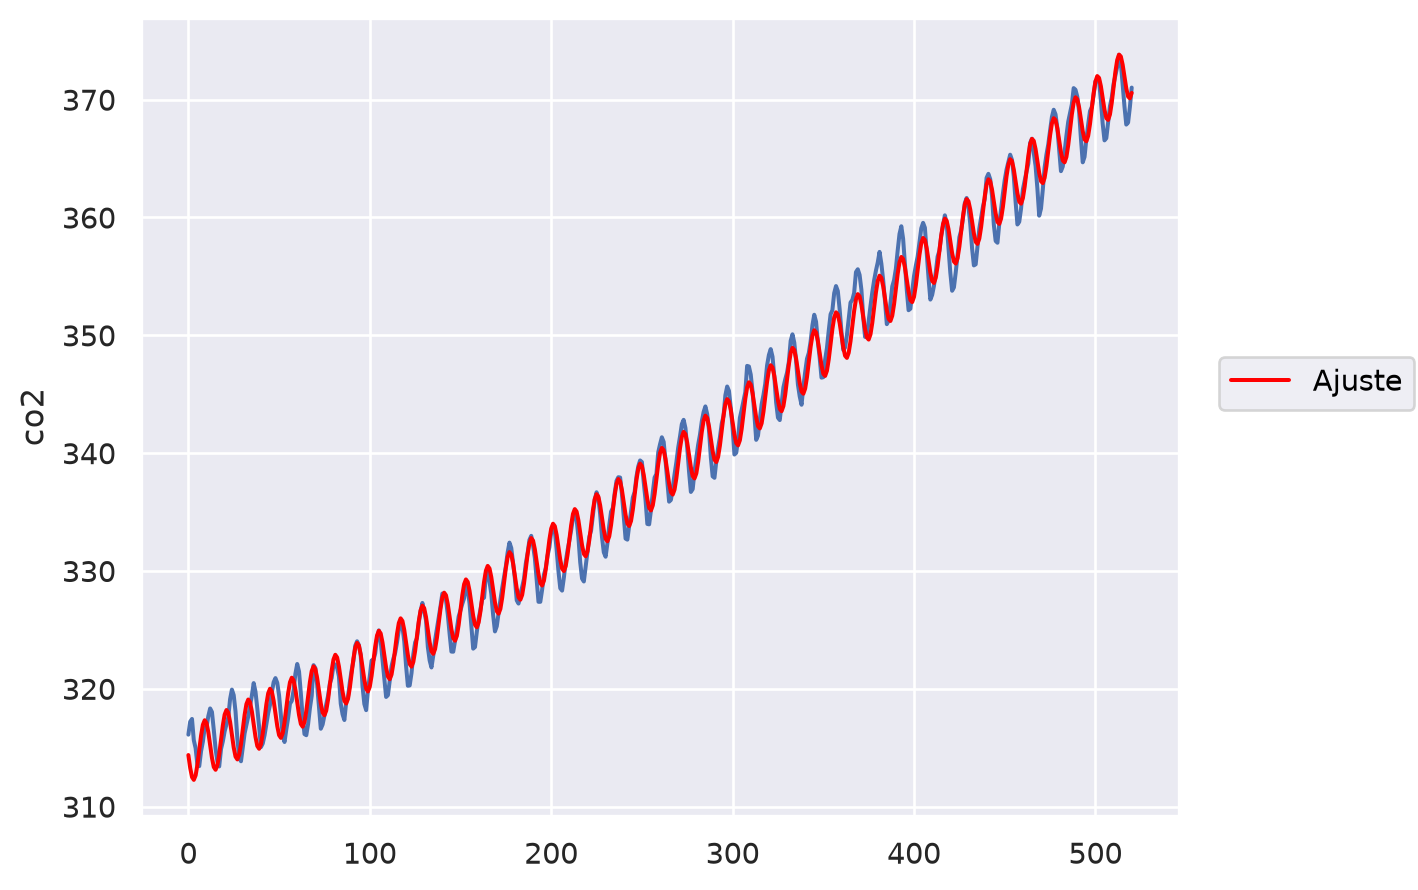

In [33]:
# Predecimos
y_pred_mejorado = modeloCO2_mejorado.predict(X)

# Graficamos
(
    so.Plot()  # Podemos usar también x = data.index pero no se ve bien
    .add(so.Line(), data=data, x = mes, y="co2")
    .add(so.Line(color = "red"), x=mes, y=y_pred_mejorado, label='Ajuste')
)

In [34]:
# Calculando el R^2
r2 = r2_score(data["co2"], y_pred_mejorado)
print('R^2: ', r2)

R^2:  0.9932705550879718


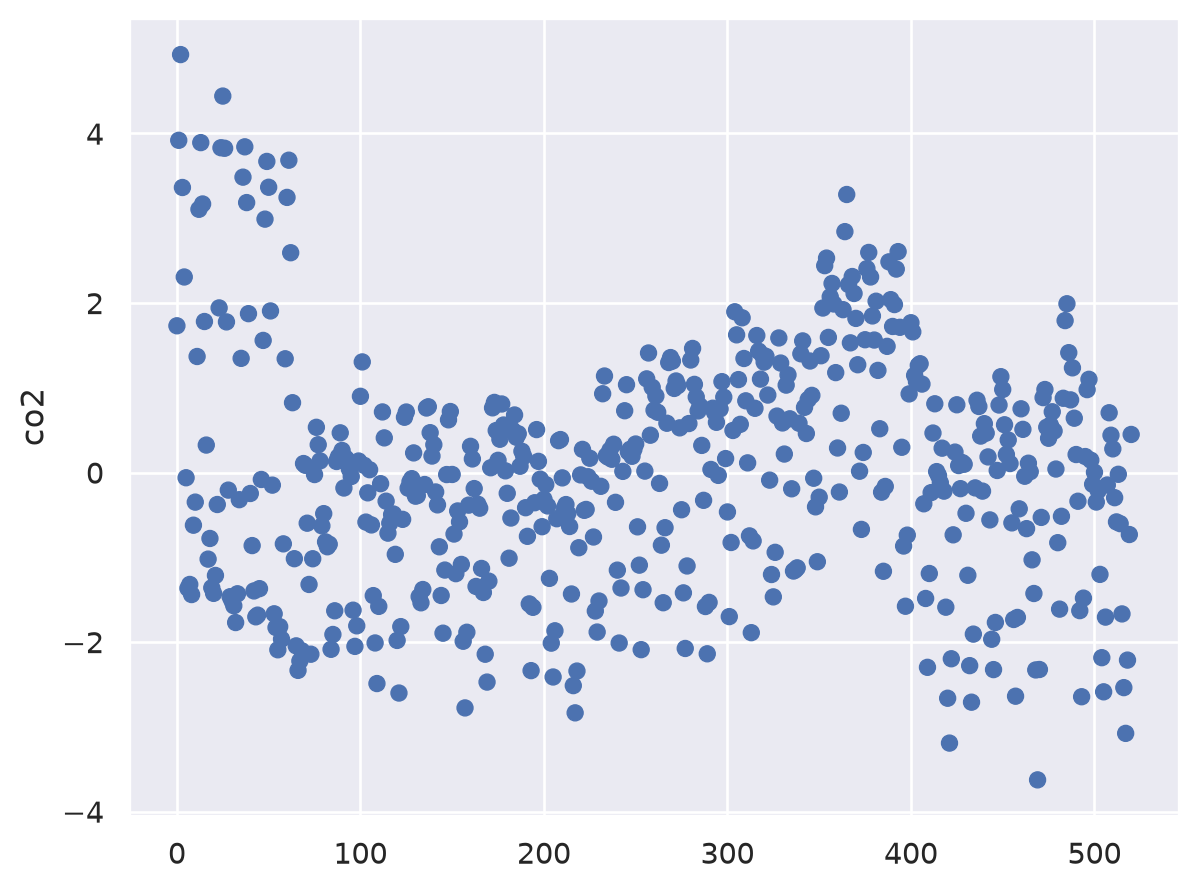

In [35]:
residuos = data["co2"] - y_pred_mejorado
(
    so.Plot(x=mes, y=residuos)
    .add(so.Dot())
)

Al incorporar un término cuadrático al modelo logré un mejor r2 y una dispersión de los residuos mas distribuida.